**CAR PRICE PREDICITON MODEL**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statistics as st

In [ ]:
data=pd.read_csv('/content/CarPrice_Assignment.csv')
data.head(5)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
data.duplicated().sum()
data.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


Text(0, 0.5, 'price')

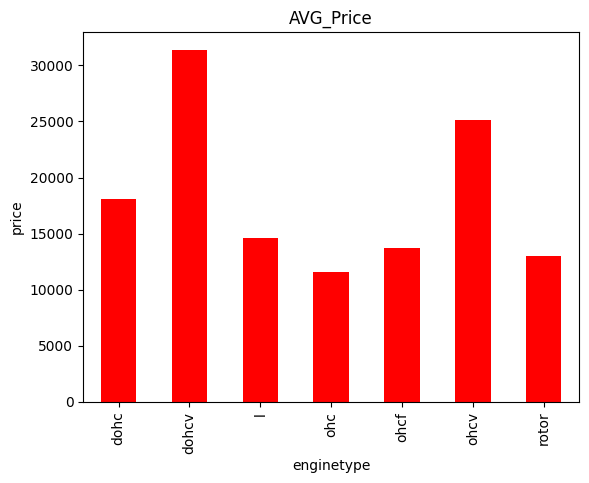

In [ ]:
avgprice=data.groupby('enginetype')['price'].mean()
avgprice
avgprice.plot(kind='bar',color='red')
plt.title('AVG_Price')
plt.xlabel('enginetype')
plt.ylabel('price')

# plt.bar(data['enginetype'],data['price'])
# plt.show()

<Axes: >

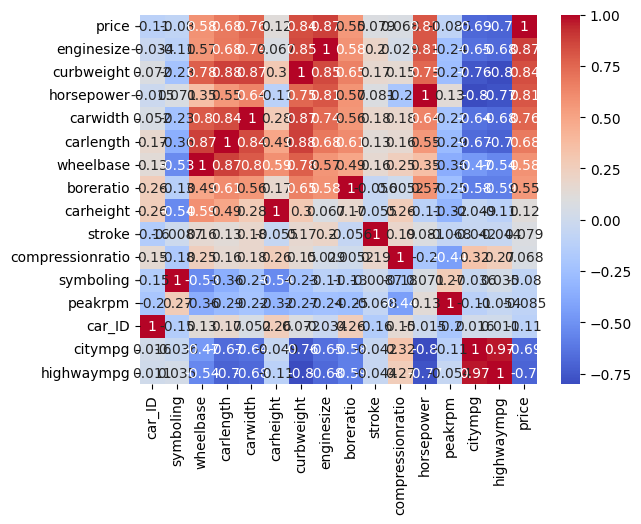

In [ ]:
corr_cars=data.corr(numeric_only=True).sort_values('price',ascending=False)
corr_cars
sns.heatmap(corr_cars,annot=True, cmap='coolwarm')

In [ ]:
data.columns

Index(['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize',
       'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

In [ ]:
x=data[['enginesize','enginetype','horsepower','curbweight']]
y=data['price']
x=pd.get_dummies(x,drop_first=True)
x.head()

,enginesize,horsepower,curbweight,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor
0,130,111,2548,False,False,False,False,False,False
1,130,111,2548,False,False,False,False,False,False
2,152,154,2823,False,False,False,False,True,False
3,109,102,2337,False,False,True,False,False,False
4,136,115,2824,False,False,True,False,False,False


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [ ]:
model=LinearRegression()
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2, random_state=2)


In [ ]:
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
print(r2_score(y_test, y_pred))

0.6549368855005706
